<a href="https://colab.research.google.com/github/AamnahFaiyaz/CodSoft/blob/main/Movie_Rating_Prediction/Aamnah%20Faiyaz%20Movie%20Rating%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🚀 IMDb Movie Rating Prediction

This notebook aims to build a Machine Learning regression model to predict movie ratings based on various features such as genre, director, actors, duration, and votes using the IMDb Movies India dataset.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


### 1. Loading the Dataset

We will load the IMDb Movies India dataset directly from the provided GitHub RAW link.

In [ ]:
# Define the dataset URL
dataset_url = "https://raw.githubusercontent.com/AamnahFaiyaz/CodeSoft/main/Movie%20Rating%20Prediction/IMDb%20Movies%20India.csv"

# Load the dataset into a Pandas DataFrame
try:
    df = pd.read_csv(dataset_url, encoding='latin-1') # Use latin-1 encoding to handle potential character issues
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")


Dataset loaded successfully!


### 2. Displaying and Understanding the Dataset

Let's get a first look at the data by displaying the first few rows, checking its information, and statistical summary.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [ ]:
# Display descriptive statistics of the numerical columns
display(df.describe(include='all'))


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


### 3. Data Preprocessing and Handling Missing Values

Based on the `df.info()` and `df.describe()` outputs, we need to perform several preprocessing steps:

1.  **Drop rows with missing 'Rating'**: Since 'Rating' is our target variable, rows without a rating are not useful for training the model.
2.  **Clean and convert 'Year'**: Extract the year as an integer from the string `(YYYY)`.
3.  **Clean and convert 'Duration'**: Extract the duration in minutes as an integer.
4.  **Clean and convert 'Votes'**: Convert the string representation of votes (e.g., '8,881') to an integer.
5.  **Handle empty 'Name' entries**: Replace empty string names with `NaN` and drop them if necessary.
6.  **Handle other missing values**: Impute or drop missing values for 'Genre', 'Director', and 'Actor' columns.

In [ ]:
# Drop rows where 'Rating' is NaN
df.dropna(subset=['Rating'], inplace=True)
print(f"DataFrame shape after dropping rows with missing Ratings: {df.shape}")


DataFrame shape after dropping rows with missing Ratings: (7919, 10)


In [ ]:
# Clean 'Year' column: Extract year from '(YYYY)' and convert to int
df['Year'] = df['Year'].str.extract('(\d+)').astype(float)
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year'] = df['Year'].astype(int)
print("Cleaned 'Year' column.")


Cleaned 'Year' column.


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_392/2880771472.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d+)').astype(float)


In [ ]:
# Clean 'Duration' column: Remove ' min' and convert to int
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
# Fill missing duration with median
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Duration'] = df['Duration'].astype(int)
print("Cleaned 'Duration' column.")


Cleaned 'Duration' column.


In [ ]:
# Clean 'Votes' column: Remove commas and convert to int
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
# Fill missing votes with median, then convert to int
df['Votes'] = df['Votes'].fillna(df['Votes'].median())
df['Votes'] = df['Votes'].astype(int)
print("Cleaned 'Votes' column.")


Cleaned 'Votes' column.


In [ ]:
# Handle empty strings in 'Name' column if any (replace with NaN, then drop)
df['Name'].replace('', np.nan, inplace=True)
df.dropna(subset=['Name'], inplace=True)
print(f"DataFrame shape after handling empty 'Name': {df.shape}")


DataFrame shape after handling empty 'Name': (7919, 10)


/tmp/ipykernel_392/2892848030.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Name'].replace('', np.nan, inplace=True)


In [ ]:
# Recheck data types and missing values after initial cleaning
print("\nDataFrame Info after initial cleaning:")
print(df.info())

print("\nMissing values after initial cleaning:")
print(df.isnull().sum())



DataFrame Info after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  7919 non-null   int64  
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 680.5+ KB
None

Missing values after initial cleaning:
Name          0
Year          0
Duration      0
Genre       102
Rating        0
Votes         0
Director      5
Actor 1     125
Actor 2     200
Actor 3     292
dtype: int64


### Handling Remaining Missing Values

We will now address the remaining missing values in categorical columns like 'Genre', 'Director', and 'Actor' columns by filling them with 'Unknown'.

In [ ]:
# Fill missing values in categorical columns with 'Unknown'
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col].fillna('Unknown', inplace=True)

print("Missing values in categorical columns filled with 'Unknown'.")

# Verify no more missing values in these columns
print("\nMissing values after filling categorical columns:")
print(df.isnull().sum())


Missing values in categorical columns filled with 'Unknown'.

Missing values after filling categorical columns:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


/tmp/ipykernel_392/3561754310.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


### 4. Feature Engineering

Now, let's perform some feature engineering to extract more meaningful information from the existing columns. This includes handling multi-value genres and potentially combining actor information.

In [ ]:
# The 'Genre' column often contains multiple genres separated by commas.
# We will split these into individual genres and then prepare them for one-hot encoding.

# First, let's see the unique genres
print("Original unique genres (first 20):\n", df['Genre'].value_counts().head(20))

# Create a list of all unique genres
all_genres = df['Genre'].str.split(', ').explode().unique()
print(f"\nTotal unique genres found: {len(all_genres)}")

# For simplicity and to avoid too many columns, we can create dummy variables for each genre
# This will generate a new column for each unique genre with binary values (0 or 1)

# Apply one-hot encoding to 'Genre' column. Each movie can have multiple genres.
# We'll create a new dataframe for genres, then merge it with the original df.

genre_dummies = df['Genre'].str.get_dummies(sep=', ')
df = pd.concat([df, genre_dummies], axis=1)

# Drop the original 'Genre' column as we have its one-hot encoded representation
df.drop('Genre', axis=1, inplace=True)

print("\nDataFrame after one-hot encoding 'Genre' column. New columns added.")
print(df.head())
print(f"\nNew DataFrame shape: {df.shape}")


Original unique genres (first 20):
 Genre
Drama                      1177
Drama, Romance              447
Action, Crime, Drama        417
Action                      417
Drama, Family               291
Action, Drama               271
Comedy                      259
Comedy, Drama               239
Romance                     234
Comedy, Drama, Romance      213
Action, Comedy, Drama       142
Thriller                    132
Action, Drama, Romance      129
Horror                      129
Comedy, Romance             120
Action, Thriller            113
Drama, Musical, Romance     103
Unknown                     102
Action, Comedy, Crime        89
Documentary                  84
Name: count, dtype: int64

Total unique genres found: 23

DataFrame after one-hot encoding 'Genre' column. New columns added.
                                 Name  Year  Duration  Rating  Votes  \
1  #Gadhvi (He thought he was Gandhi)  2019       109     7.0      8   
3                             #Yaaram  2019     

### Current DataFrame State after initial cleaning and Genre OHE

Let's check the DataFrame's current state before proceeding with Director and Actor feature engineering.

In [ ]:
display(df.head())
print(df.info())


,Name,Year,Duration,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Musical,Mystery,News,Romance,Sci-Fi,Sport,Thriller,Unknown,War,Western
1,#Gadhvi (He thought he was Gandhi),2019,109,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,#Yaaram,2019,110,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
5,...Aur Pyaar Ho Gaya,1997,147,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
6,...Yahaan,2005,142,7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
8,?: A Question Mark,2012,82,5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0


<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         7919 non-null   object 
 1   Year         7919 non-null   int64  
 2   Duration     7919 non-null   int64  
 3   Rating       7919 non-null   float64
 4   Votes        7919 non-null   int64  
 5   Director     7919 non-null   object 
 6   Actor 1      7919 non-null   object 
 7   Actor 2      7919 non-null   object 
 8   Actor 3      7919 non-null   object 
 9   Action       7919 non-null   int64  
 10  Adventure    7919 non-null   int64  
 11  Animation    7919 non-null   int64  
 12  Biography    7919 non-null   int64  
 13  Comedy       7919 non-null   int64  
 14  Crime        7919 non-null   int64  
 15  Documentary  7919 non-null   int64  
 16  Drama        7919 non-null   int64  
 17  Family       7919 non-null   int64  
 18  Fantasy      7919 non-null   int64  
 19  History   

### Feature Engineering for Director and Actors

To handle the high cardinality of 'Director' and 'Actor' columns, we will identify the top N most frequent directors and actors and create binary features (one-hot encoding) for their presence. For actors, we'll first combine `Actor 1`, `Actor 2`, and `Actor 3` into a single list of all actors involved in a movie.

In [ ]:
# Define the number of top directors/actors to consider
TOP_N = 100

# --- Director Feature Engineering ---
print(f"\nProcessing Director column (Top {TOP_N})...")
if 'Director' in df.columns:
    top_directors = df['Director'].value_counts().head(TOP_N).index.tolist()

    for director in top_directors:
        df[f'Director_{director}'] = df['Director'].apply(lambda x: 1 if director in x else 0)

    # Drop the original 'Director' column
    df.drop('Director', axis=1, inplace=True)
    print("Director features created and original column dropped.")
else:
    print("'Director' column already processed or not found.")

# --- Actor Feature Engineering ---
print(f"\nProcessing Actor columns (Top {TOP_N})...")
if 'Actor 1' in df.columns and 'Actor 2' in df.columns and 'Actor 3' in df.columns:
    # Combine Actor 1, Actor 2, Actor 3 into a single series of all actors
    all_actors_series = pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']]).dropna()
    top_actors = all_actors_series.value_counts().head(TOP_N).index.tolist()

    for actor in top_actors:
        df[f'Actor_{actor}'] = df.apply(lambda row: 1 if actor in [row['Actor 1'], row['Actor 2'], row['Actor 3']] else 0, axis=1)

    # Drop the original 'Actor' columns
    df.drop(['Actor 1', 'Actor 2', 'Actor 3'], axis=1, inplace=True)
    print("Actor features created and original columns dropped.")
else:
    print("Actor columns already processed or not found.")


Processing Director column (Top 100)...
'Director' column already processed or not found.

Processing Actor columns (Top 100)...


/tmp/ipykernel_392/646962515.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'Actor_{actor}'] = df.apply(lambda row: 1 if actor in [row['Actor 1'], row['Actor 2'], row['Actor 3']] else 0, axis=1)
/tmp/ipykernel_392/646962515.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'Actor_{actor}'] = df.apply(lambda row: 1 if actor in [row['Actor 1'], row['Actor 2'], row['Actor 3']] else 0, axis=1)
/tmp/ipykernel_392/646962515.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

Actor features created and original columns dropped.


/tmp/ipykernel_392/646962515.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'Actor_{actor}'] = df.apply(lambda row: 1 if actor in [row['Actor 1'], row['Actor 2'], row['Actor 3']] else 0, axis=1)


### Final DataFrame State after Feature Engineering

Let's review the DataFrame's structure and contents after all the feature engineering steps for 'Genre', 'Director', and 'Actors'.

In [ ]:
display(df.head())
print(df.info())


,Name,Year,Duration,Rating,Votes,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Musical,Mystery,News,Romance,Sci-Fi,Sport,Thriller,Unknown,War,Western,Director_Mahesh Bhatt,Director_David Dhawan,Director_Hrishikesh Mukherjee,Director_Shakti Samanta,Director_Kanti Shah,Director_Rama Rao Tatineni,Director_Ram Gopal Varma,Director_Basu Chatterjee,Director_Vikram Bhatt,Director_Shibu Mitra,Director_Raj N. Sippy,Director_K. Raghavendra Rao,Director_Priyadarshan,Director_K. Bapaiah,Director_Harmesh Malhotra,Director_T.L.V. Prasad,Director_Shantaram Rajaram Vankudre,Director_Raj Khosla,Director_Shyam Ramsay,Director_Satyen Bose,Director_Babubhai Mistry,Director_Ravikant Nagaich,Director_Manmohan Desai,Director_Shyam Benegal,Director_Yash Chopra,Director_Prakash Mehra,Director_B.R. Ishara,Director_Saawan Kumar Tak,Director_Subhash Ghai,Director_Partho Ghosh,Director_Mahesh Manjrekar,Director_Gulzar,Director_Kedar Kapoor,Director_Dev Anand,Director_Ravi Tandon,Director_Mehul Kumar,Director_Brij,Director_Pramod Chakravorty,Director_Abbas Alibhai Burmawalla,Director_K.C. Bokadia,Director_J. Om Prakash,Director_Rahul Rawail,Director_Deepak Bahry,Director_Lawrence D'Souza,Director_B.R. Chopra,Director_Mohan Segal,Director_Rajkumar Kohli,Director_A. Bhimsingh,Director_Nanabhai Bhatt,Director_Anil Ganguly,Director_Chetan Anand,Director_Vijay Anand,Director_Umesh Mehra,Director_Mohammed Hussain,Director_Raj Kanwar,Director_Ananth Narayan Mahadevan,Director_Prakash Jha,Director_Bimal Roy,Director_Babbar Subhash,Director_Kalpataru,Director_Abdul Rashid Kardar,Director_Esmayeel Shroff,Director_Narayana Rao Dasari,Director_Ajay Kashyap,Director_Mehboob Khan,Director_T. Prakash Rao,Director_Homi Wadia,Director_Dulal Guha,Director_Anil Sharma,Director_K. Ravi Shankar,Director_N. Chandra,Director_Narendra Bedi,Director_Mohan Kumar,Director_Devendra Goel,Director_Rajiv S. Ruia,Director_Khwaja Ahmad Abbas,Director_Rajkumar Santoshi,Director_K. Amarnath,Director_S.P. Muthuraman,Director_Deepak Balraj Vij,Director_Madhur Bhandarkar,Director_Anurag Kashyap,Director_Indra Kumar,Director_Satish Kaushik,Director_Bhappi Sonie,Director_M. Sadiq,Director_Sudhir Mishra,Director_Lekh Tandon,Director_Chand,Director_Rohit Shetty,Director_Nitin Bose,Director_Guddu Dhanoa,Director_K. Muralimohana Rao,Director_Bapu,Director_Govind Nihalani,Director_Debaki Bose,Director_Ashok Gaekwad,Director_Rakesh Roshan,Director_Harnam Singh Rawail,Director_Naresh Kumar,Actor_Unknown,Actor_Mithun Chakraborty,Actor_Dharmendra,Actor_Jeetendra,Actor_Ashok Kumar,Actor_Amitabh Bachchan,Actor_Rekha,Actor_Rajesh Khanna,Actor_Shashi Kapoor,Actor_Sanjay Dutt,Actor_Shatrughan Sinha,Actor_Akshay Kumar,Actor_Jackie Shroff,Actor_Govinda,Actor_Sanjeev Kumar,Actor_Raj Babbar,Actor_Rishi Kapoor,Actor_Vinod Khanna,Actor_Dev Anand,Actor_Hema Malini,Actor_Shabana Azmi,Actor_Naseeruddin Shah,Actor_Anil Kapoor,Actor_Ajay Devgn,Actor_Pran,Actor_Anupam Kher,Actor_Sunny Deol,Actor_Asrani,Actor_Salman Khan,Actor_Sunil Shetty,Actor_Sunil Dutt,Actor_Mala Sinha,Actor_Shammi Kapoor,Actor_Sridevi,Actor_Zeenat Aman,Actor_Rakhee Gulzar,Actor_Shakti Kapoor,Actor_Reena Roy,Actor_Om Puri,Actor_Juhi Chawla,Actor_Vinod Mehra,Actor_Mumtaz,Actor_Ajit,Actor_Meena Kumari,Actor_Saif Ali Khan,Actor_Rajendra Kumar,Actor_Prem Chopra,Actor_Raveena Tandon,Actor_Sharmila Tagore,Actor_Pradeep Kumar,Actor_Shah Rukh Khan,Actor_Balraj Sahni,Actor_Jaya Prada,Actor_Nutan,Actor_Sadashiv Amrapurkar,Actor_Raj Kapoor,Actor_Dimple Kapadia,Actor_Waheeda Rehman,Actor_Paresh Rawal,Actor_Karisma Kapoor,Actor_Rajinikanth,Actor_Bharat Bhushan,Actor_Dilip Kumar,Actor_Rati Agnihotri,Actor_Feroz Khan,Actor_Madhuri Dixit,Actor_Kishore Kumar,Actor_Raaj Kumar,Actor_Manisha Koirala,Actor_Manoj Bajpayee,Actor_Tabu,Actor_Mehmood,Actor_Moushumi Chatterjee,Actor_Asha Parekh,Actor_Danny Denzongpa,Actor_Jimmy Sheirgill,Actor_Amrish Puri,Actor_Rakesh Bedi,Actor_Nirupa Roy,Actor_Madhubala,Actor_Smita Pat

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Columns: 228 entries, Name to Actor_Emraan Hashmi
dtypes: float64(1), int64(226), object(1)
memory usage: 13.8+ MB
None


### 5. Data Visualization

Let's visualize the data to understand the distributions and relationships between features, especially with the target variable 'Rating'.

We'll start by visualizing the distribution of movie ratings and then explore how other features might relate to it.

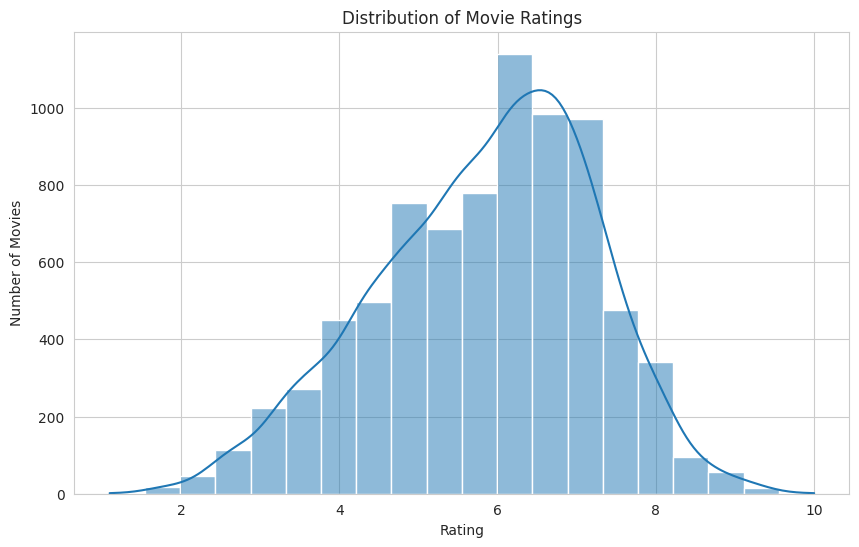

In [ ]:
# Set style for seaborn plots
sns.set_style("whitegrid")

# Distribution of Movie Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()


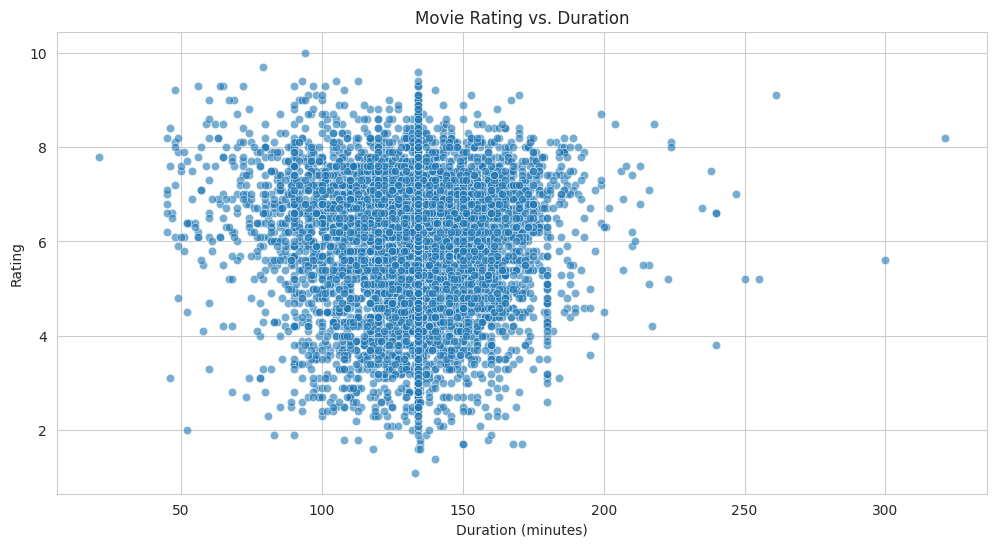

In [ ]:
# Relationship between Duration and Rating
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Duration', y='Rating', data=df, alpha=0.6)
plt.title('Movie Rating vs. Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')
plt.show()


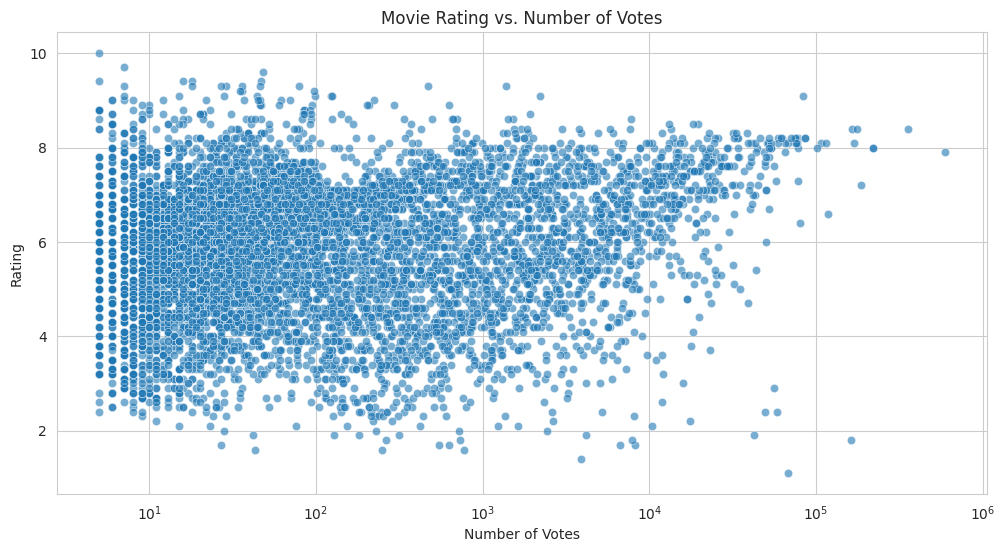

In [ ]:
# Relationship between Votes and Rating
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Votes', y='Rating', data=df, alpha=0.6)
plt.title('Movie Rating vs. Number of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.xscale('log') # Use log scale for votes for better visualization due to wide range
plt.show()


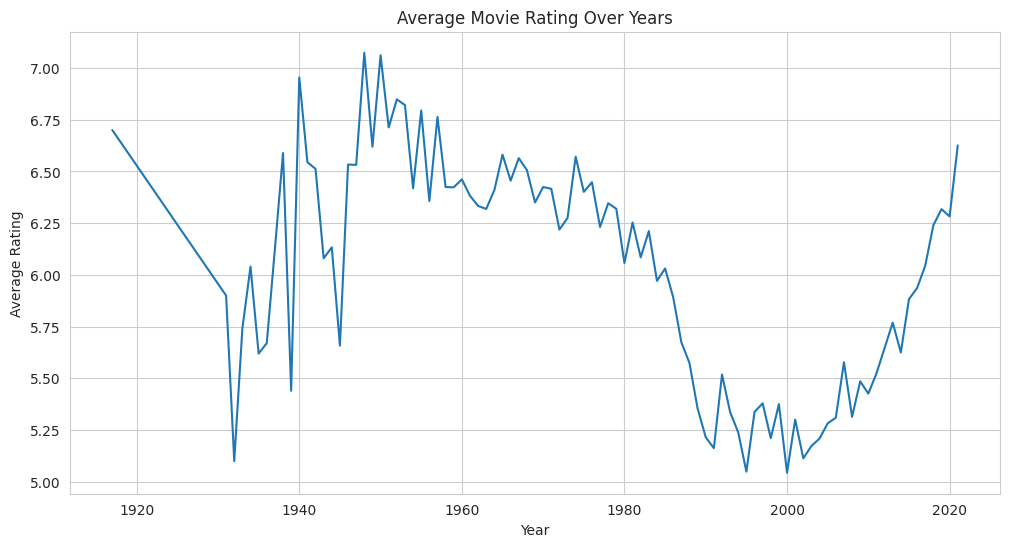

In [ ]:
# Relationship between Year and Rating
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Rating', data=df.groupby('Year')['Rating'].mean().reset_index())
plt.title('Average Movie Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()


### Correlation Heatmap

Let's visualize the correlation matrix of numerical features and a sample of the newly created binary features to see how they relate to each other and to the target variable 'Rating'.

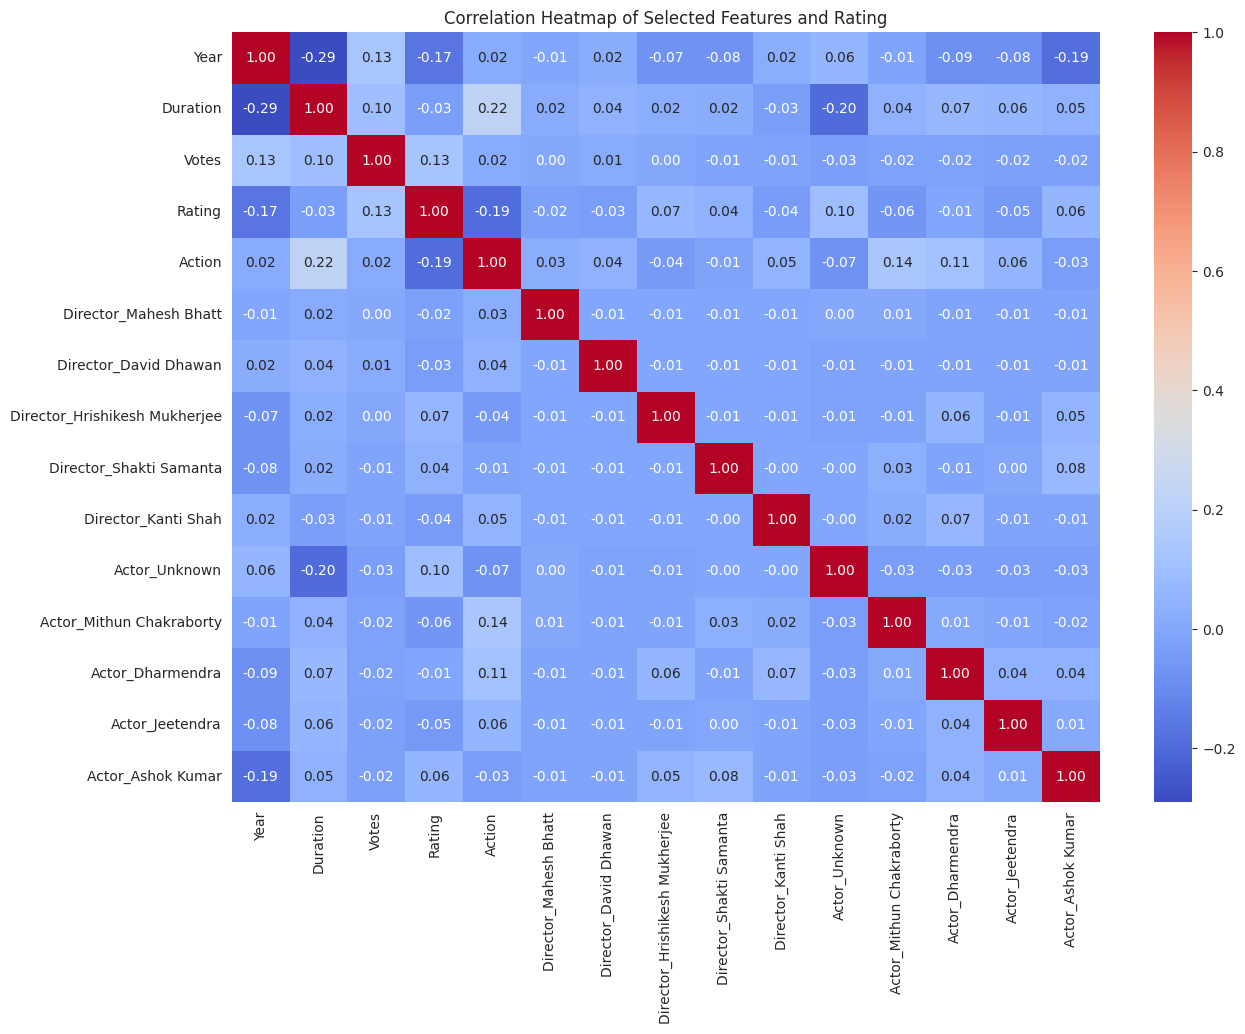

In [ ]:
# Select a subset of columns for the heatmap to avoid overcrowding
# Include numerical columns and a few sample one-hot encoded features

# Identify numerical columns
numerical_cols = ['Year', 'Duration', 'Votes', 'Rating']

# Identify one-hot encoded genre columns (take first 5 for example)
genre_cols = [col for col in df.columns if col.startswith('Action')][:5]

# Identify one-hot encoded director columns (take first 5 for example)
director_cols = [col for col in df.columns if col.startswith('Director_')][:5]

# Identify one-hot encoded actor columns (take first 5 for example)
actor_cols = [col for col in df.columns if col.startswith('Actor_')][:5]

# Combine selected columns
selected_cols = numerical_cols + genre_cols + director_cols + actor_cols

# Calculate correlation matrix
correlation_matrix = df[selected_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Features and Rating')
plt.show()


### 6. Splitting the Dataset into Training and Testing Sets

Before training our machine learning model, we need to divide our dataset into features (X) and the target variable (y). Our target variable is 'Rating'. Then, we'll split these into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'Name' as it's an identifier and not directly useful as a feature after initial processing
# 'Rating' is our target variable

X = df.drop(columns=['Name', 'Rating'])
y = df['Rating']

# Split the dataset into training and testing sets
# We'll use 80% for training and 20% for testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (6335, 226)
Shape of X_test: (1584, 226)
Shape of y_train: (6335,)
Shape of y_test: (1584,)


### 7. Training a Regression-based Machine Learning Model

We will train a simple regression model to predict movie ratings. For this task, we will use the `RandomForestRegressor` from scikit-learn, as it is robust and generally performs well. We will also scale numerical features for better model performance, although tree-based models are less sensitive to scaling.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical columns for scaling
# Note: 'Year', 'Duration', 'Votes' are numerical. One-hot encoded features are already binary (0/1).
# We should exclude the one-hot encoded columns from standard scaling.

numerical_features = ['Year', 'Duration', 'Votes']

# Create a pipeline for preprocessing and model training
# This is a basic example; for more complex scenarios, ColumnTransformer would be used.

# For simplicity, we'll apply StandardScaler only to the identified numerical features if they exist in X_train

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler only on the training data's numerical features
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_features])
X_test_scaled_numerical = scaler.transform(X_test[numerical_features])

# Create DataFrames with scaled numerical features
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_features, index=X_train.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_features, index=X_test.index)

# Combine scaled numerical features with other (already binary/categorical) features
# Ensure to drop original numerical columns from X_train/X_test before concatenating scaled ones
# Also, identify and drop any remaining non-numerical (object) columns
object_cols_to_drop = X_train.select_dtypes(include='object').columns.tolist()

X_train_processed = pd.concat([X_train.drop(columns=numerical_features + object_cols_to_drop), X_train_scaled_numerical_df], axis=1)
X_test_processed = pd.concat([X_test.drop(columns=numerical_features + object_cols_to_drop), X_test_scaled_numerical_df], axis=1)

# Initialize the Random Forest Regressor model
# Set random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
print("\nTraining the RandomForestRegressor model...")
model.fit(X_train_processed, y_train)
print("Model training complete!")

# Make predictions on the processed test set immediately after training
y_pred = model.predict(X_test_processed)
print("Predictions made on the test set.")


Training the RandomForestRegressor model...
Model training complete!
Predictions made on the test set.


### 8. Making Predictions

Now that the model is trained, let's make predictions on the test set.

In [ ]:
# This cell is now redundant as predictions are made in the training cell.
# It will be kept here as a placeholder if you wish to run predictions separately again in the future.
# y_pred = model.predict(X_test_processed)
# print("Predictions made on the test set.")


### 9. Evaluating the Model

We will evaluate the model's performance using common regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² ) Score: {r2:.4f}")


Mean Absolute Error (MAE): 0.8150
Mean Squared Error (MSE): 1.1848
Root Mean Squared Error (RMSE): 1.0885
R-squared (R² ) Score: 0.3627


### 10. Visualizing Prediction Results

To better understand the model's performance, let's visualize the actual vs. predicted ratings.

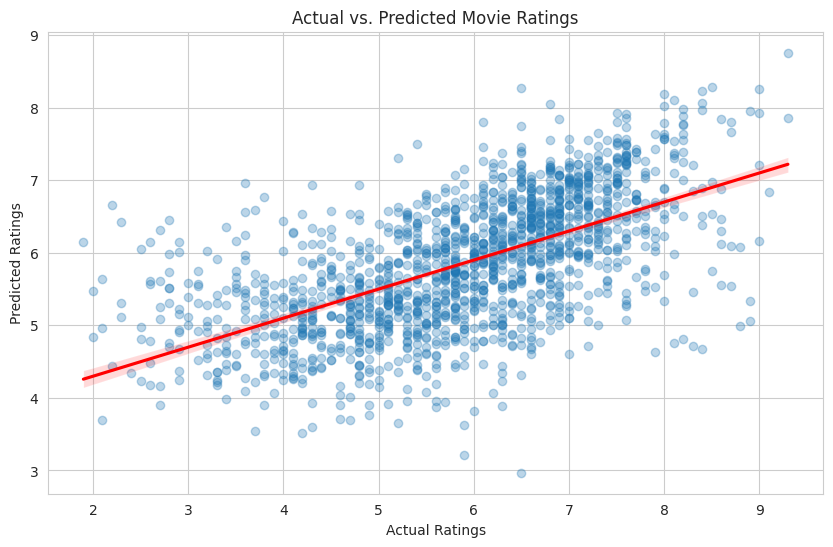

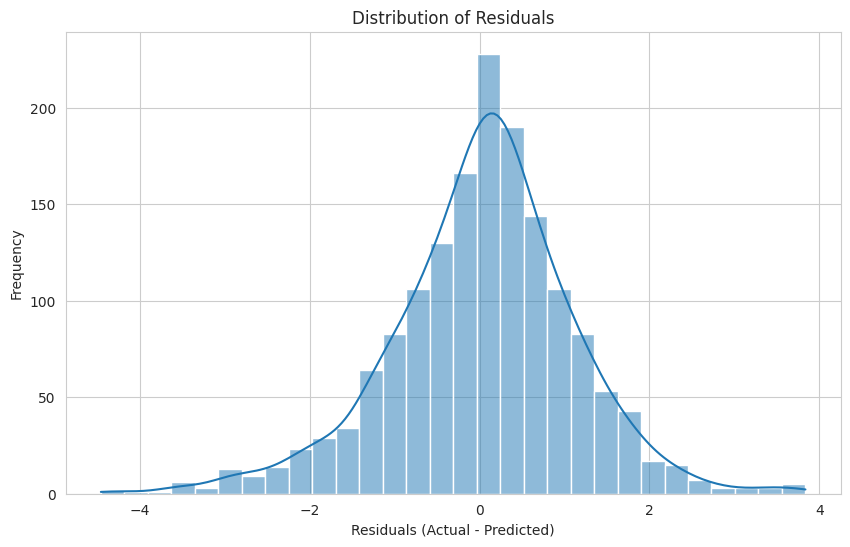

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual vs. Predicted Movie Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.grid(True)
plt.show()

# Distribution of Residuals (Errors)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()
